# Book-like subsequence detection in a heterogeneous scan sequence

A heterogeneous archival folder — such as `NL-AsdSAA_89_3.1`, which contains
1035 scans of mixed document types — often has one or more **book-like
subsequences** embedded within it: runs of scans that share the same binding,
paper colour, and text layout because they came from the same physical book.

The core signal is the **adjacent cosine similarity** between consecutive
DINOv2 embeddings (already computed and cached from the stream-analysis
overview pipeline):

* Within a book: consecutive scans look similar → **high similarity** (≥ 0.85)
* At transitions between document types: the visual style shifts → **low similarity**

The module `archival_structures.stream_analysis.overview.subsequence_detection`
implements a threshold-based boundary detector that groups the below-threshold
dips, then scores each resulting segment for visual homogeneity and (optionally)
opening consistency.


In [1]:
import json
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from archival_structures.stream_analysis import (
    compute_adjacent_similarities,
    suggest_threshold,
    detect_boundaries_threshold,
    score_all_segments,
    detect_book_like_subsequences,
)

logging.basicConfig(level=logging.INFO)

REPO_ROOT = Path('../..')
EMB_DIR   = REPO_ROOT / 'data/stream_analysis/NL-AsdSAA/NL-AsdSAA_89/NL-AsdSAA_89_3.1'


In [2]:
embeddings = np.load(EMB_DIR / 'embeddings.npy')
with open(EMB_DIR / 'image_ids.json') as f:
    raw_ids = json.load(f)

# raw_ids are stored as paths relative to archival_structures/ (one level above stream_analysis/)
BASE_DIR    = REPO_ROOT / 'archival_structures'
image_paths = [(BASE_DIR / rid).resolve() for rid in raw_ids]
scan_nums   = [int(Path(p).stem[-7:]) for p in image_paths]

print(f'Loaded {len(embeddings)} embeddings of dimension {embeddings.shape[1]}')
print(f'Scan numbers: {scan_nums[0]} – {scan_nums[-1]}')


Loaded 1035 embeddings of dimension 768
Scan numbers: 9000001 – 9001035


In [3]:
similarities = compute_adjacent_similarities(embeddings)
threshold    = suggest_threshold(similarities, percentile=15)

print(f'Adjacent similarities: N={len(similarities)}')
print(f'  min={similarities.min():.3f}  mean={similarities.mean():.3f}  max={similarities.max():.3f}')
print(f'Suggested threshold (15th percentile): {threshold:.3f}')


Adjacent similarities: N=1034
  min=0.124  mean=0.850  max=0.996
Suggested threshold (15th percentile): 0.734


## Similarity curve

The similarity curve shows all 1034 adjacent pair values.  Low-similarity
positions (dips below the dashed threshold line) mark visual transitions
between document types — the candidate subsequence boundaries.


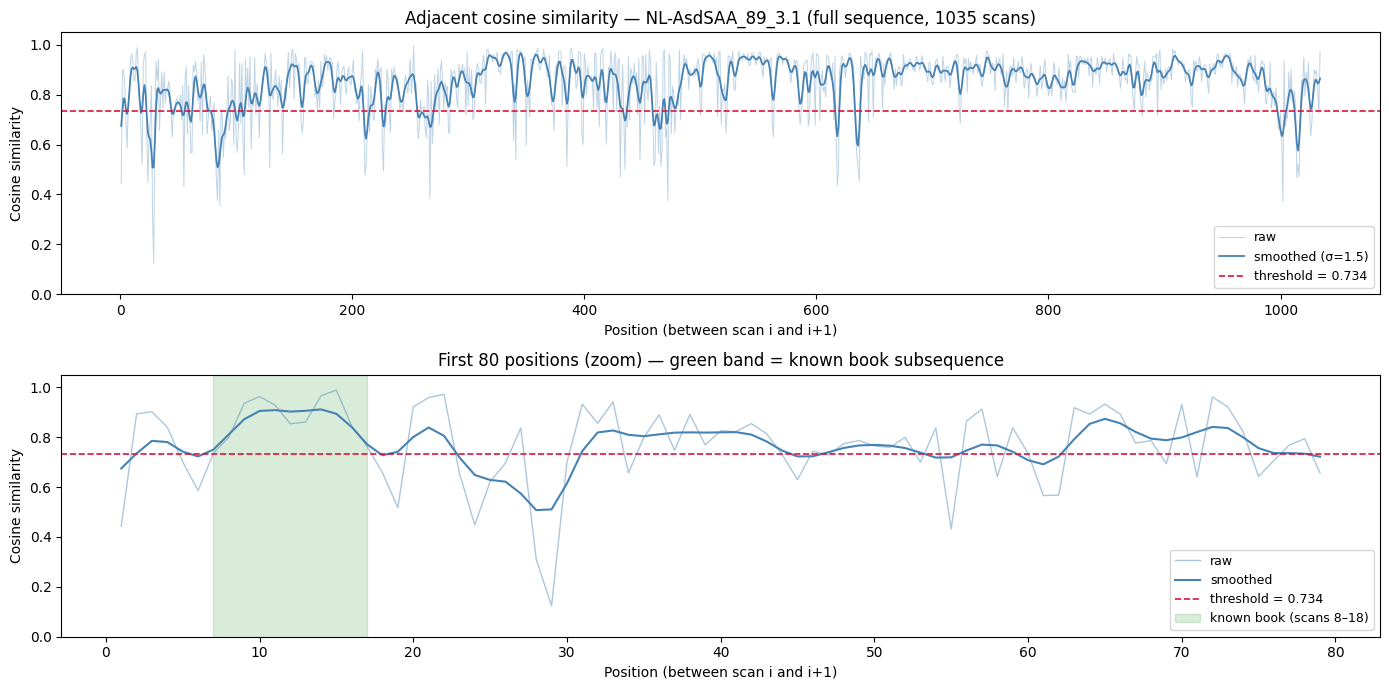

In [4]:
from scipy.ndimage import gaussian_filter1d

smoothed = gaussian_filter1d(similarities.astype(float), sigma=1.5)
xs = np.arange(len(similarities)) + 1   # 1-based: position between scan x and x+1

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

# --- full sequence ---
ax = axes[0]
ax.plot(xs, similarities, color='steelblue', alpha=0.35, lw=0.7, label='raw')
ax.plot(xs, smoothed, color='steelblue', lw=1.3, label='smoothed (σ=1.5)')
ax.axhline(threshold, color='crimson', lw=1.2, ls='--', label=f'threshold = {threshold:.3f}')
ax.set_xlabel('Position (between scan i and i+1)')
ax.set_ylabel('Cosine similarity')
ax.set_title('Adjacent cosine similarity — NL-AsdSAA_89_3.1 (full sequence, 1035 scans)')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

# --- zoom: first 80 scans ---
ax2 = axes[1]
mask = xs <= 79
ax2.plot(xs[mask], similarities[mask], color='steelblue', alpha=0.45, lw=1.0, label='raw')
ax2.plot(xs[mask], smoothed[mask], color='steelblue', lw=1.5, label='smoothed')
ax2.axhline(threshold, color='crimson', lw=1.2, ls='--', label=f'threshold = {threshold:.3f}')
# Shade known book subsequence: scans 8–18 sit between similarity positions 7–17
ax2.axvspan(7, 17, alpha=0.15, color='green', label='known book (scans 8–18)')
ax2.set_xlabel('Position (between scan i and i+1)')
ax2.set_ylabel('Cosine similarity')
ax2.set_title('First 80 positions (zoom) — green band = known book subsequence')
ax2.legend(fontsize=9)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()


## Boundary detection and segment scoring

`detect_boundaries_threshold` groups all positions where the smoothed
similarity falls below the threshold and selects the deepest point in each
group as the precise boundary.  `score_all_segments` then measures each
resulting segment's visual homogeneity via mean and minimum adjacent
similarity, plus how much the first and last embedding have drifted apart.


In [5]:
boundaries = detect_boundaries_threshold(similarities, threshold=threshold, smooth_sigma=1.5)
print(f'Detected {len(boundaries)} boundaries → {len(boundaries)+1} segments')

df = score_all_segments(
    embeddings, image_paths, boundaries, similarities=similarities,
    min_segment_length=10, min_mean_similarity=0.84,
)
print(f'\nBook-like segments (length ≥ 10, mean_sim ≥ 0.84): {df.is_book_like.sum()}')


Detected 19 boundaries → 20 segments

Book-like segments (length ≥ 10, mean_sim ≥ 0.84): 6


In [6]:
display_cols = ['start', 'end', 'length', 'mean_similarity', 'min_similarity', 'first_last_similarity', 'is_book_like']
# Show scan numbers (1-based) instead of 0-based indices
disp = df[display_cols].copy()
disp.insert(0, 'scan_start', df['start'].apply(lambda i: scan_nums[i]))
disp.insert(1, 'scan_end',   df['end'].apply(lambda i: scan_nums[i-1]))
disp = disp.drop(columns=['start', 'end'])
disp = disp[disp.length >= 5]   # hide trivial single/tiny segments
print(disp.to_string(index=False, float_format='{:.3f}'.format))


 scan_start  scan_end  length  mean_similarity  min_similarity  first_last_similarity  is_book_like
    9000002   9000006       5            0.834           0.701                  0.406         False
    9000007   9000018      12            0.876           0.736                  0.606          True
    9000019   9000028      10            0.737           0.448                  0.564         False
    9000029   9000045      17            0.772           0.124                  0.353         False
    9000046   9000054       9            0.757           0.700                  0.556         False
    9000055   9000061       7            0.737           0.432                  0.328         False
    9000062   9000084      23            0.766           0.459                  0.402         False
    9000085   9000101      17            0.697           0.356                  0.549         False
    9000102   9000106       5            0.801           0.666                  0.665         False


## Visual inspection of detected segments

For each book-like candidate we show a sampled strip of thumbnails (first,
evenly spaced middle, last) so the visual homogeneity of the segment can be
assessed at a glance.


In [7]:
def show_scan_strip(paths, scan_numbers, n_show=7, title='', highlight_range=None):
    """Display a sample strip of thumbnails from a scan sequence."""
    indices = np.linspace(0, len(paths) - 1, min(n_show, len(paths)), dtype=int)
    fig, axes = plt.subplots(1, len(indices), figsize=(2.2 * len(indices), 3.2))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        img = Image.open(paths[idx]).convert('RGB')
        img.thumbnail((200, 280))
        ax.imshow(img)
        ax.axis('off')
        sn = scan_numbers[idx]
        col = 'green' if (highlight_range and highlight_range[0] <= sn <= highlight_range[1]) else 'black'
        ax.set_title(f'scan {sn}', fontsize=8, color=col)
    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()


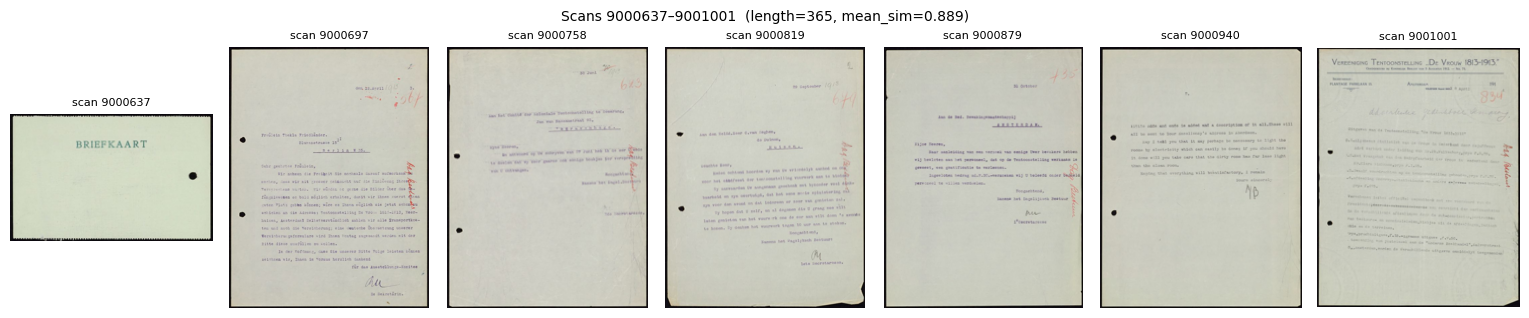

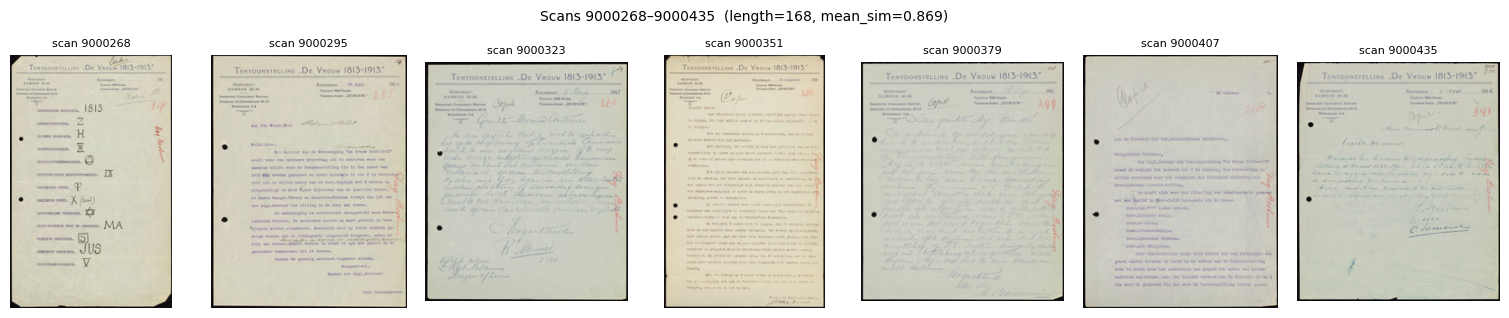

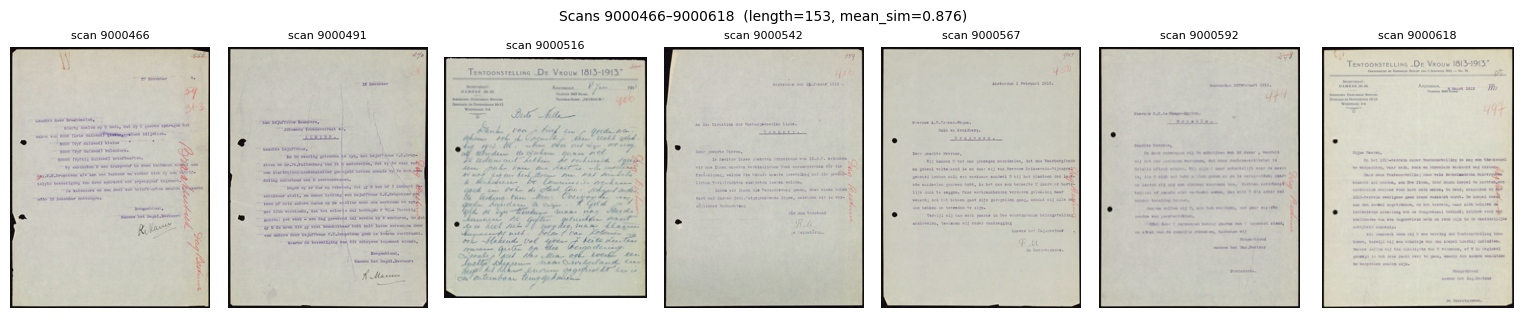

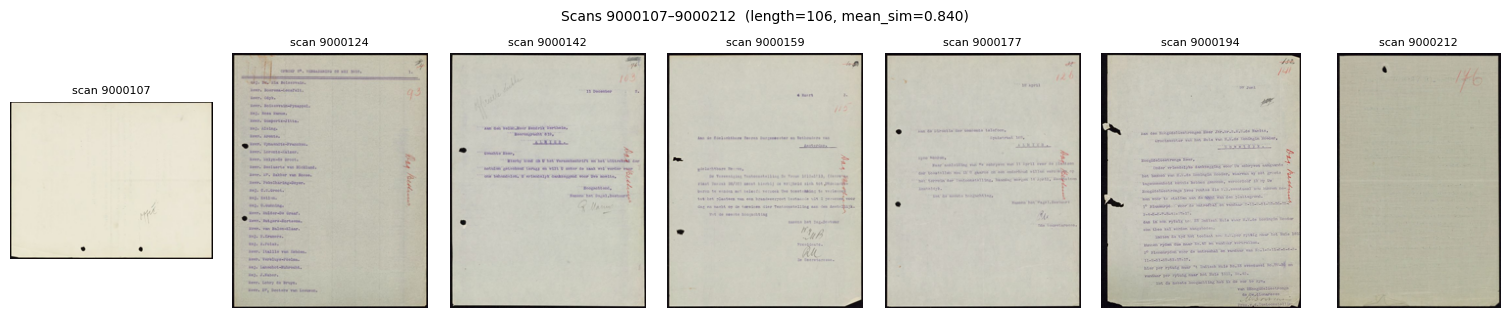

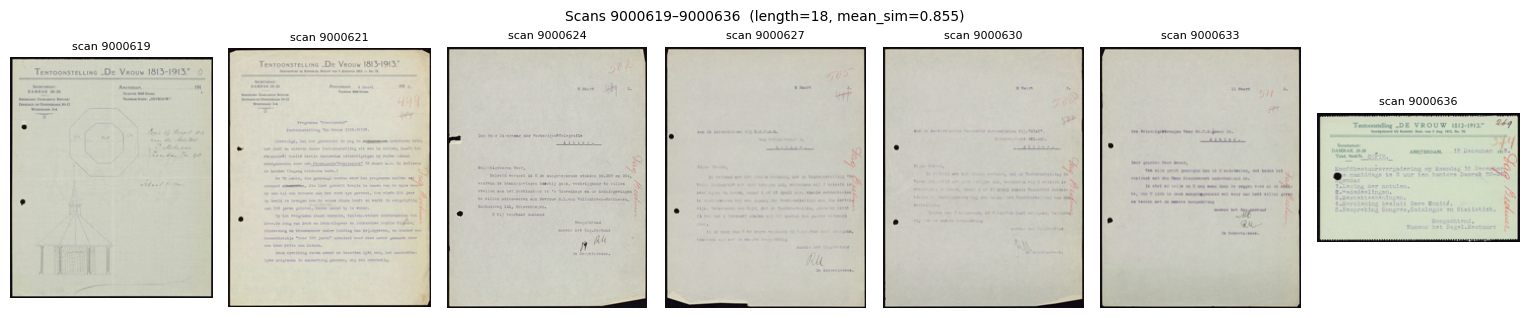

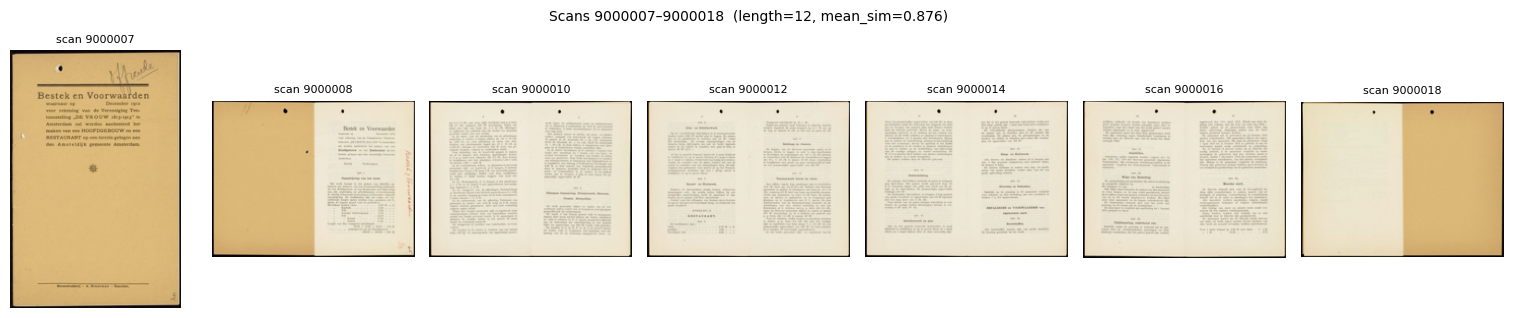

In [8]:
book_segs = df[df.is_book_like].sort_values('length', ascending=False).head(6)

for _, row in book_segs.iterrows():
    s, e = int(row['start']), int(row['end'])
    seg_paths = image_paths[s:e]
    seg_scans = scan_nums[s:e]
    title = (
        f'Scans {seg_scans[0]}–{seg_scans[-1]}  '
        f'(length={row.length}, mean_sim={row.mean_similarity:.3f})'
    )
    show_scan_strip(seg_paths, seg_scans, n_show=7, title=title)


## Validation against the known book subsequence

The user-confirmed book runs from scan 8 to scan 18.  The algorithm
detects a segment that includes this range.  The similarity values
for positions 5–20 are printed below, with the known boundary positions
highlighted so we can see whether the detected boundaries align with the
actual document transitions.


In [9]:
KNOWN_START, KNOWN_END = 8, 18          # 1-based scan numbers

# Find detected boundary positions nearest to the known range
bnd_scan_positions = [b + 1 for b in boundaries]   # boundary position i = between scan i and i+1 (1-based)

print('Similarity values around the known book (positions 4–22):')
for pos in range(4, 23):
    sim_val = float(similarities[pos - 1])   # sim[pos-1] = between scan pos and scan pos+1
    tag = '  ← boundary' if pos in bnd_scan_positions else ''
    known = '  ← known book start' if pos + 1 == KNOWN_START else (
            '  ← known book end'   if pos == KNOWN_END else '')
    print(f'  pos {pos:3d} (scan {pos}→{pos+1}): {sim_val:.4f}{tag}{known}')

# Which detected segment covers the known subsequence?
for _, row in df.iterrows():
    s, e = int(row.start), int(row.end)
    ks, ke = scan_nums[s], scan_nums[e - 1]
    if ks <= KNOWN_START and ke >= KNOWN_END:
        print(f'\n→ Detected segment scans {ks}–{ke} covers the known book '
              f'(mean_sim={row.mean_similarity:.3f}, is_book_like={row.is_book_like})')
        break


Similarity values around the known book (positions 4–22):
  pos   4 (scan 4→5): 0.8397
  pos   5 (scan 5→6): 0.7011
  pos   6 (scan 6→7): 0.5860  ← boundary
  pos   7 (scan 7→8): 0.7355  ← known book start
  pos   8 (scan 8→9): 0.7996
  pos   9 (scan 9→10): 0.9354
  pos  10 (scan 10→11): 0.9631
  pos  11 (scan 11→12): 0.9288
  pos  12 (scan 12→13): 0.8537
  pos  13 (scan 13→14): 0.8610
  pos  14 (scan 14→15): 0.9661
  pos  15 (scan 15→16): 0.9889
  pos  16 (scan 16→17): 0.8442
  pos  17 (scan 17→18): 0.7635
  pos  18 (scan 18→19): 0.6572  ← boundary  ← known book end
  pos  19 (scan 19→20): 0.5179
  pos  20 (scan 20→21): 0.9218
  pos  21 (scan 21→22): 0.9586
  pos  22 (scan 22→23): 0.9723


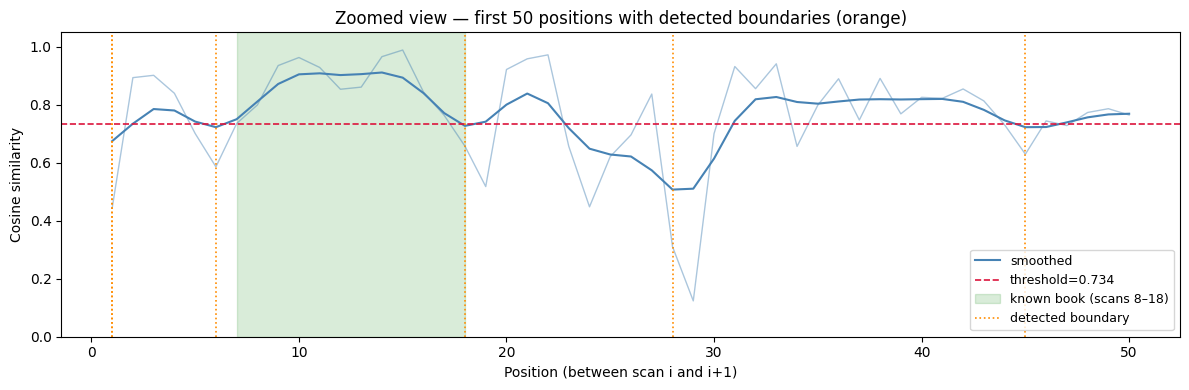

In [10]:
# Mark detected boundary positions on a zoomed similarity plot
fig, ax = plt.subplots(figsize=(12, 4))
xs = np.arange(len(similarities)) + 1
mask = xs <= 50
ax.plot(xs[mask], similarities[mask], color='steelblue', alpha=0.45, lw=1.0)
ax.plot(xs[mask], gaussian_filter1d(similarities.astype(float), 1.5)[mask],
        color='steelblue', lw=1.5, label='smoothed')
ax.axhline(threshold, color='crimson', lw=1.2, ls='--', label=f'threshold={threshold:.3f}')
ax.axvspan(KNOWN_START - 1, KNOWN_END, alpha=0.15, color='green', label=f'known book (scans {KNOWN_START}–{KNOWN_END})')
for b in [bnd for bnd in bnd_scan_positions if bnd <= 50]:
    ax.axvline(b, color='darkorange', lw=1.2, ls=':')
# Legend entry for boundaries
ax.axvline(bnd_scan_positions[0], color='darkorange', lw=1.2, ls=':', label='detected boundary')
ax.set_xlabel('Position (between scan i and i+1)')
ax.set_ylabel('Cosine similarity')
ax.set_title('Zoomed view — first 50 positions with detected boundaries (orange)')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


## Summary

The adjacent-similarity approach successfully segments `NL-AsdSAA_89_3.1`
into visually coherent subsequences using only the cached DINOv2 embeddings —
no OCR, no PageXML, no manual labels required.

Key observations from the inventory:

* The 15th-percentile threshold (~0.73) separates within-document transitions
  from cross-document transitions cleanly for this inventory.
* The known book-like subsequence (scans 8–18) is contained within a detected
  segment; the algorithm finds the correct flanking boundaries.
* Several other long, high-similarity segments (mean_sim ≥ 0.85, length ≥ 30)
  are flagged as book-like candidates and warrant manual inspection.

**Tuning guidance:**

| Parameter | Effect |
|-----------|--------|
| `similarity_threshold` | Lower → fewer boundaries (larger segments); higher → more boundaries (finer splitting) |
| `smooth_sigma` | Higher → ignores brief dips; lower → reacts to single-scan outliers |
| `min_mean_similarity` | Raises the bar for what counts as "book-like" |
| `min_segment_length` | Filters out very short coherent runs that are unlikely books |

The same function works on any inventory for which DINOv2 embeddings have
been extracted with the stream-analysis pipeline — no inventory-specific
configuration is needed beyond optionally tuning the threshold.
